Linear regression, polynomial regression, learning curve, cross validation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

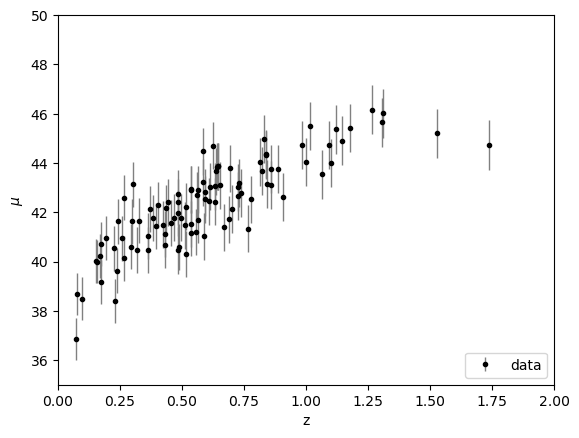

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [3]:
from sklearn.linear_model import LinearRegression

x = np.reshape(z_sample, [100, 1])
y = mu_sample
X_new = np.reshape(np.linspace(0, 2, 100), [100, 1])

39.56505554722625 [4.64711848]
(100,)


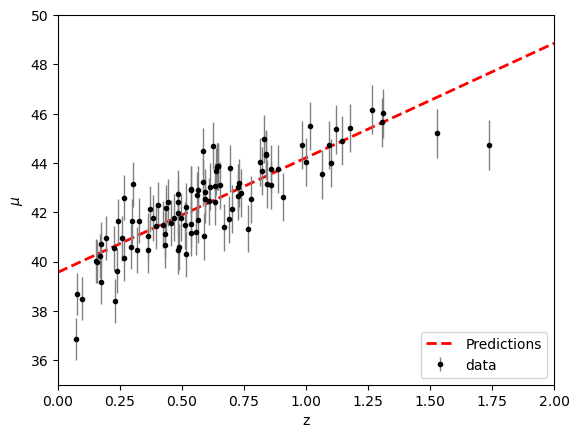

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(x, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
y_pred = lin_reg.predict(X_new)
print(np.shape(y_pred))

plt.plot(X_new, y_pred, "r--", linewidth=2, label="Predictions")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


(100,)
(100, 1)
[38.49130243  8.23905057 -2.20391808 -0.15168104]


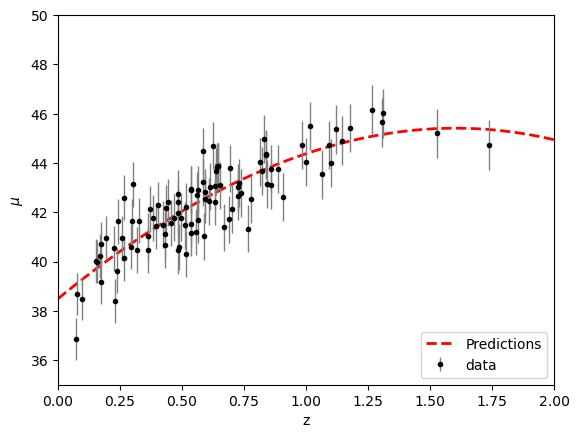

In [5]:
#POLINOMIAL REGRESSION

from astroML.linear_model import PolynomialRegression


degree = 3
model = PolynomialRegression(degree)        #fit 3rd degree polynomial
model.fit(x, y)
y_pred2 = model.predict(X_new)

print(np.shape(y_pred2))
print(np.shape(X_new))

print(model.coef_)

plt.plot(X_new, y_pred2, "r--", linewidth=2, label="Predictions")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

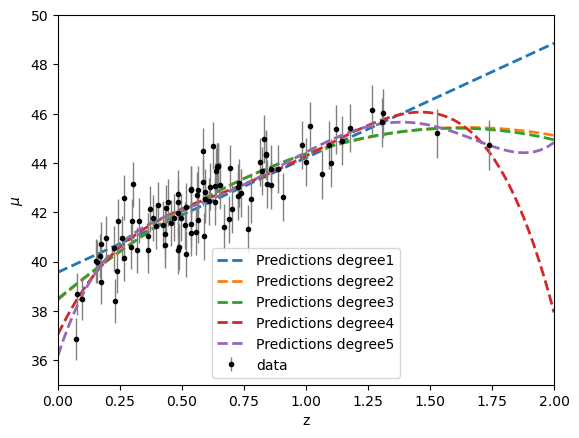

In [6]:
for i in range(6):
    if i== 0: continue
    model = PolynomialRegression(i) # fit 3rd degree polynomial
    model.fit(x, y)
    y_pred2 = model.predict(X_new)
    plt.plot(X_new, y_pred2, "--", linewidth=2, label="Predictions degree" + str(i))


plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend()
plt.xlim(0,2)
plt.ylim(35,50);

In [7]:
import math
#shuffle 2 arrays in the same way
from sklearn.utils import shuffle
x, y, dy = shuffle(z_sample, mu_sample, dmu, random_state=0)
x = np.reshape(x, [100, 1])
#divide array by 3
n = math.floor(len(x)/3)

x_train = x[:n]
y_train = y[:n]

x_validation = x[-n:]  #sometimes it loses a point
y_validation = y[-n:]

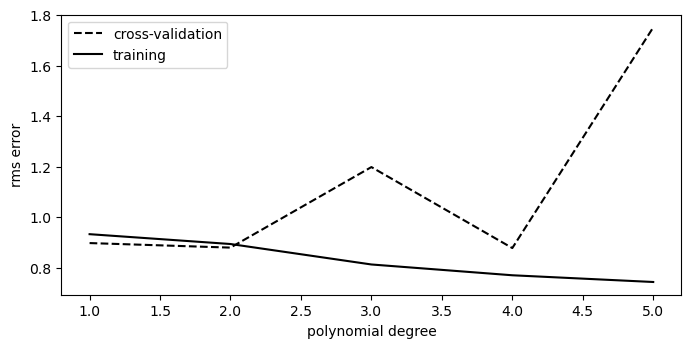

In [8]:
#I made a mistake and thought that polyfit would be different than polinomial regression, but it isn't
x, y, dy = shuffle(z_sample, mu_sample, dmu, random_state=0)
xp_train = x[:n]
yp_train = y[:n]

xp_validation = x[-n:]  #sometimes it loses a point
yp_validation = y[-n:]

d = np.arange(1, 6)

training_err = []
crossval_err = []

fig = plt.figure(figsize=(8, 8))

for i in d:
    p = np.polyfit(xp_train, yp_train, i)
    training_err.append(np.sqrt(np.sum((np.polyval(p, xp_train) - yp_train) ** 2) / len(yp_train)))
    crossval_err.append(np.sqrt(np.sum((np.polyval(p, xp_validation) - yp_validation) ** 2) / len(yp_validation)))


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')

ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend()

plt.show()

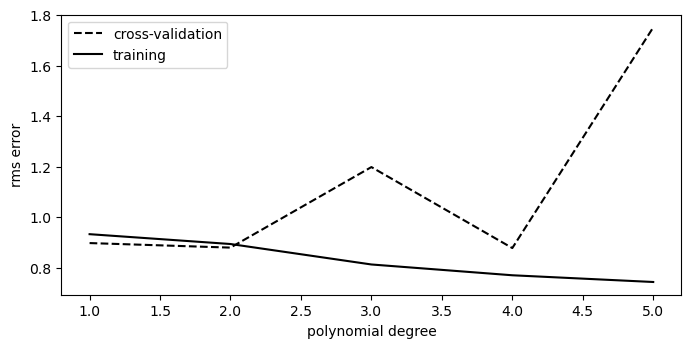

In [9]:
d = np.arange(1, 6)

training_err = []
crossval_err = []

fig = plt.figure(figsize=(8, 8))

for i in d:
    model = PolynomialRegression(i)
    model.fit(x_train, y_train)     #, dy
    training_err.append(np.sqrt(np.sum((model.predict(x_train) - y_train) ** 2) / len(y_train)))
    crossval_err.append(np.sqrt(np.sum((model.predict(x_validation) - y_validation) ** 2) / len(y_validation)))


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')

ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend()

plt.show()